In [52]:
import h5py
import numpy as np

def extract_mat_file(filepath):
    """
    Extract BFData and ReconParams from a MATLAB v7.3 .mat file
    """
    # Load the file
    f = h5py.File(filepath, 'r')
    
    # Extract BFData
    BFData_dict = {}
    bfdata_group = f['BFData']
    
    # Get the complex arrays (IQ_xAM and IQ_xBmode)
    for array_name in ['IQ_xAM', 'IQ_xBMode']:
        if array_name in bfdata_group:
            # Load the raw data
            raw_data = bfdata_group[array_name][:]
            
            # Check the dtype and convert appropriately
            if 'complex' in str(raw_data.dtype):
                # Already complex type
                BFData_dict[array_name] = raw_data
            elif raw_data.dtype == np.float64 or raw_data.dtype == np.float32:
                # Real data only
                BFData_dict[array_name] = raw_data
            else:
                # Try to interpret as complex (MATLAB v7.3 stores complex as real+imag in structured dtype)
                try:
                    # Check if it's a structured array with real and imag fields
                    if raw_data.dtype.names is not None:
                        if 'real' in raw_data.dtype.names and 'imag' in raw_data.dtype.names:
                            complex_data = raw_data['real'] + 1j * raw_data['imag']
                            BFData_dict[array_name] = complex_data
                        else:
                            # Try to access fields dynamically
                            fields = list(raw_data.dtype.names)
                            if len(fields) >= 2:
                                complex_data = raw_data[fields[0]] + 1j * raw_data[fields[1]]
                                BFData_dict[array_name] = complex_data
                            else:
                                BFData_dict[array_name] = raw_data
                    else:
                        BFData_dict[array_name] = raw_data
                except:
                    BFData_dict[array_name] = raw_data
            
            print(f"Loaded {array_name} with shape: {BFData_dict[array_name].shape}, dtype: {BFData_dict[array_name].dtype}")
        elif array_name.lower() in [k.lower() for k in bfdata_group.keys()]:
            # Case-insensitive fallback
            actual_name = next(k for k in bfdata_group.keys() if k.lower() == array_name.lower())
            raw_data = bfdata_group[actual_name][:]
            
            # Same conversion logic
            if 'complex' in str(raw_data.dtype):
                BFData_dict[actual_name] = raw_data
            elif raw_data.dtype == np.float64 or raw_data.dtype == np.float32:
                BFData_dict[actual_name] = raw_data
            else:
                try:
                    if raw_data.dtype.names is not None:
                        if 'real' in raw_data.dtype.names and 'imag' in raw_data.dtype.names:
                            complex_data = raw_data['real'] + 1j * raw_data['imag']
                            BFData_dict[actual_name] = complex_data
                        else:
                            fields = list(raw_data.dtype.names)
                            if len(fields) >= 2:
                                complex_data = raw_data[fields[0]] + 1j * raw_data[fields[1]]
                                BFData_dict[actual_name] = complex_data
                            else:
                                BFData_dict[actual_name] = raw_data
                    else:
                        BFData_dict[actual_name] = raw_data
                except:
                    BFData_dict[actual_name] = raw_data
            
            print(f"Loaded {actual_name} with shape: {BFData_dict[actual_name].shape}, dtype: {BFData_dict[actual_name].dtype}")
    
    # Extract ReconParams
    ReconParams_dict = {}
    reconparams_group = f['ReconParams']
    
    for key in reconparams_group.keys():
        item = reconparams_group[key]
        data = item[:] if isinstance(item, h5py.Dataset) else item
        
        # Convert to scalar if it's a 1x1 array
        if isinstance(item, h5py.Dataset) and data.size == 1:
            data = data.item()
        # Remove any extra dimensions
        elif isinstance(data, np.ndarray) and data.size == 1:
            data = data.item()
        
        ReconParams_dict[key] = data
    
    f.close()
    return BFData_dict, ReconParams_dict

In [53]:
data_dir = "./data/BioUSElective_20260506_JTLRYTAA/ST/"
filepath = data_dir + "data_20260506_164831_ST_5.9Vmat_20260506_165551.mat"

BFData, ReconParams = extract_mat_file(filepath)

Loaded IQ_xAM with shape: (260, 180), dtype: complex64
Loaded IQ_xBMode with shape: (260, 180), dtype: complex64


In [54]:
ReconParams.keys()

dict_keys(['Angles', 'DemodulationFrequency', 'DemodulationMode', 'FNumber', 'GridNx', 'GridNy', 'GridNz', 'GridOrigin', 'GridScaleX', 'GridScaleY', 'GridScaleZ', 'InterpolationMode', 'NFramesPerBatch', 'NRays', 'NSamplesPerTx', 'NTxPerFrame', 'PiezoXPos', 'PiezoYPos', 'PiezoZPos', 'PointSourceDistOffset', 'PointSourceX', 'PointSourceZ', 'SamplingFrequency', 'SequenceMode', 'SpeedOfSound', 'TXDistOffset', 'TimeCorrectionLens', 'TimeCorrectionStartDepth', 'TimeCorrectionWaveform', 'TransConnector'])

In [85]:
import numpy as np
import matplotlib.pyplot as plt

def plot_beamformed_image(BFData, ReconParams, mode='BMode', figsize=(10, 8), cmap='gray', show_colorbar=True):
    """
    Plot the envelope of beamformed IQ data (xAM or xBMode) with proper physical coordinates.
    
    Parameters:
    -----------
    BFData : dict
        Dictionary containing 'IQ_xAM' and/or 'IQ_xBMode' arrays
    ReconParams : dict
        Dictionary containing 'GridScaleX', 'GridScaleZ', 'GridOrigin'
    mode : str
        Either 'AM' (for IQ_xAM) or 'BMode' (for IQ_xBMode). Case-insensitive.
    figsize : tuple
        Figure size (width, height) in inches
    cmap : str
        Colormap for the image
    show_colorbar : bool
        Whether to display the colorbar
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The generated figure
    ax : matplotlib.axes.Axes
        The axes object
    """
    # Select the appropriate data
    mode = mode.lower()
    if mode == 'am':
        iq_data = BFData.get('IQ_xAM')
        title = 'Envelope of IQ_xAM'
    elif mode == 'bmode':
        iq_data = BFData.get('IQ_xBMode')
        title = 'Envelope of IQ_xBMode'
    else:
        raise ValueError("mode must be 'AM' or 'BMode'")
    
    if iq_data is None:
        raise KeyError(f"Data for mode {mode} not found in BFData")
    
    # Get physical parameters
    grid_scale_x = ReconParams['GridScaleX']  # meters per pixel (lateral)
    grid_scale_z = ReconParams['GridScaleZ']  # meters per pixel (depth)
    grid_origin = ReconParams['GridOrigin']   # [x, y, z] origin of top-left
    
    # Image dimensions: (depth, lateral)
    n_depth, n_lateral = iq_data.shape
    
    # Compute envelope (amplitude)
    envelope = np.abs(iq_data)
    
    # Physical coordinates (in meters)
    lateral_axis = grid_origin[0] + np.arange(n_lateral) * grid_scale_x
    depth_axis = grid_origin[2] + np.arange(n_depth) * grid_scale_z
    
    # Convert to mm for display
    lateral_mm = lateral_axis * 1000
    depth_mm = depth_axis * 1000
    
    # Rotate: depth on x-axis, lateral on y-axis
    envelope_rotated = envelope.T  # shape becomes (n_lateral, n_depth)
    
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(envelope_rotated,
                   extent=[lateral_mm[0], lateral_mm[-1], depth_mm[-1], depth_mm[0]],
                   aspect='auto',
                   cmap=cmap)
    
    ax.set_ylabel('Depth (mm)')
    ax.set_xlabel('Lateral Position (mm)')
    ax.set_title(title)
    ax.invert_xaxis()  # So lateral increases downward (like typical image)
    
    if show_colorbar:
        plt.colorbar(im, ax=ax, label='Amplitude')
    
    plt.tight_layout()
    return fig, ax


# Example usage:
# fig1, ax1 = plot_beamformed_image(BFData, ReconParams, mode='AM')
# fig2, ax2 = plot_beamformed_image(BFData, ReconParams, mode='BMode')

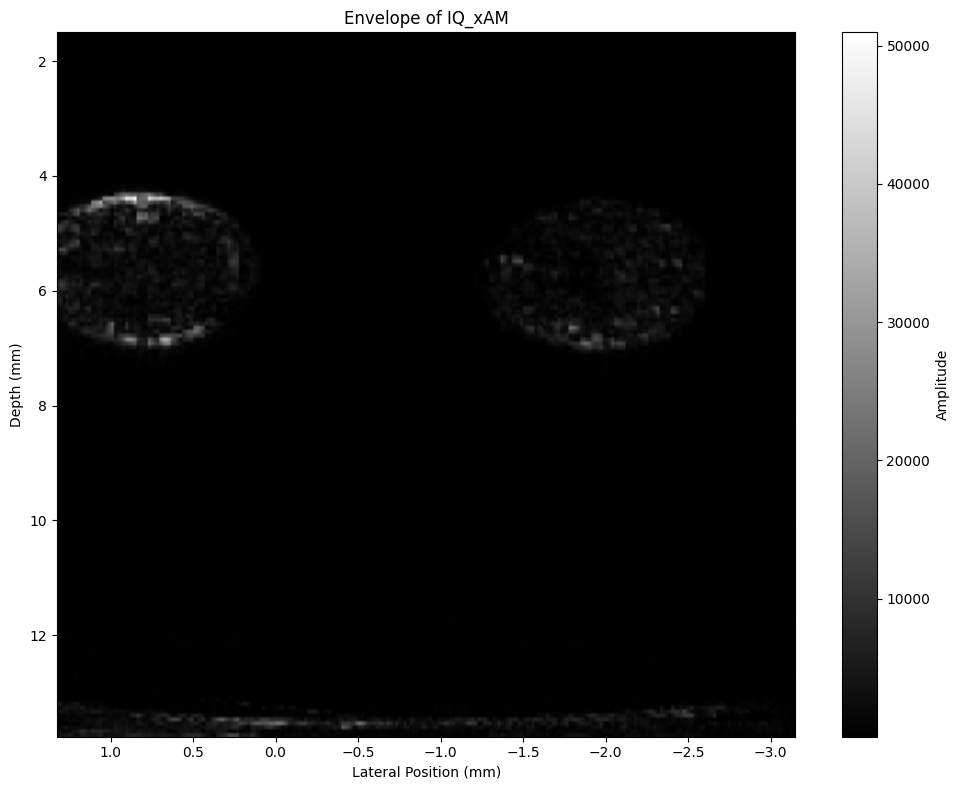

In [86]:
# Example usage:
fig1, ax1 = plot_beamformed_image(BFData, ReconParams, mode='AM')
# fig2, ax2 = plot_beamformed_image(BFData, ReconParams, mode='BMode')